<a href="https://colab.research.google.com/github/MikanQuyt/ML/blob/main/BTL1_MentalHealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link to google drive

In [ ]:
#Using while you put dataset into your googleDrive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Add necessary library

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import GridSearchCV


In [ ]:
#initialize stored dataset variable
dataset = "/content/drive/MyDrive/Dataset_BTL/BTL1_Teen_Mental_Health_Dataset.csv"

In [ ]:
try:
  #read file dataset
  df = pd.read_csv(dataset)

  #Define number of samples and attributes
  #row, col
  samples_number, attributes_number = df.shape
  print("Analyst dataset: Teen_Mental_Health_Dataset.csv")
  print(f"Number of samples: {samples_number}")
  print(f"Number of attributes: {attributes_number}")

except FileNotFoundError:
  print(f"Error: Not Found Dataset {dataset}!")

Analyst dataset: Teen_Mental_Health_Dataset.csv
Number of samples: 1200
Number of attributes: 13


In [ ]:
#Classificate the data type of each column
data_types = {
  "Numerical": [],
  "Categorical": []
}


for col in df.columns:
  if pd.api.types.is_numeric_dtype(df[col]):
    if df[col].nunique() <= 2:
      data_types["Categorical"].append(col)
    else:
      data_types["Numerical"].append(col)
  else:
    data_types["Categorical"].append(col)
print(f"Numerical: {data_types['Numerical']}")
print(f"Categorical: {data_types['Categorical']}")

Numerical: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
Categorical: ['gender', 'platform_usage', 'social_interaction_level', 'depression_label']


**Depression label is categorical part because it decribes binary number '1' and '0' such as TRUE or FALSE**

In [ ]:
#Check missing values
missing_value = df.isnull().sum()
print(f"Missing values :{display(missing_value[missing_value > 0])}")

,0


Missing values :None


In [ ]:
#Describing Statistics
numerical_cols = data_types["Numerical"]

desc_stats = df[numerical_cols].describe().loc[['mean', 'std', 'min', 'max']]
desc_stats.index = ['Mean', 'Standard Deviation', 'Min', 'Max']
table = desc_stats.transpose()
print("                           Statistic Table")
print("")
print(table)

                           Statistic Table

                               Mean  Standard Deviation   Min   Max
age                       15.928333            2.021947  13.0  19.0
daily_social_media_hours   4.536667            2.029599   1.0   8.0
sleep_hours                6.449417            1.442677   4.0   9.0
screen_time_before_sleep   1.740333            0.716660   0.5   3.0
academic_performance       2.990383            0.576758   2.0   4.0
physical_activity          1.014500            0.582185   0.0   2.0
stress_level               5.445833            2.903290   1.0  10.0
anxiety_level              5.636667            2.859453   1.0  10.0
addiction_level            5.565000            2.830627   1.0  10.0


In [ ]:
label_col = "depression_label"
counts = df[label_col].value_counts()
percentage = df[label_col].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    "Count": counts,
    "Percentage": percentage
})

print("Distribution of labels:")
print(distribution)

is_imbalanced = percentage.min() < 20
if is_imbalanced:
    print("Data is imbalanced")
else:
    print("Data is balanced")


Distribution of labels:
                  Count  Percentage
depression_label                   
0                  1169   97.416667
1                    31    2.583333
Data is imbalanced


In [ ]:
#Dropp missing values
df_cleaned = df.dropna()
print(f"Size of dataset after dropping missing values: {df_cleaned.shape}")

Size of dataset after dropping missing values: (1200, 13)


In [ ]:
#Replace missing values by mean/mode value
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

categorical_cols = data_types["Categorical"]
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after processing:")
print(df.isnull().sum())

Missing values after processing:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [ ]:
df = pd.read_csv(dataset)

In [ ]:
#Encoding Data by Label or One-Hot
level_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(level_mapping)

df = pd.get_dummies(df, columns=['gender', 'platform_usage'], dtype=int)

print(df)

      age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0      14                       7.9          7.4                       2.9   
1      19                       1.9          8.0                       2.9   
2      17                       1.3          7.6                       0.5   
3      15                       7.4          6.9                       1.6   
4      15                       4.7          4.9                       3.0   
...   ...                       ...          ...                       ...   
1195   18                       6.8          6.6                       2.0   
1196   16                       2.3          8.0                       1.9   
1197   14                       1.7          8.7                       0.7   
1198   15                       3.9          8.5                       2.1   
1199   16                       4.7          6.5                       1.0   

      academic_performance  physical_activity  social_interacti

In [ ]:
df = pd.read_csv(dataset)

In [ ]:
#Standarding Data by StandardScaler
df['social_interaction_level'] = df['social_interaction_level'].map(level_mapping)
df = pd.get_dummies(df, columns=['gender', 'platform_usage'], dtype=int)

cols_to_scale = [
    'age', 'daily_social_media_hours', 'sleep_hours',
    'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level',
    'stress_level', 'anxiety_level', 'addiction_level'
]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(df)

           age  daily_social_media_hours  sleep_hours  \
0    -0.954099                  1.657833     0.659177   
1     1.519796                 -1.299649     1.075244   
2     0.530238                 -1.595397     0.797866   
3    -0.459320                  1.411376     0.312455   
4    -0.459320                  0.080509    -1.074435   
...        ...                       ...          ...   
1195  1.025017                  1.115628     0.104421   
1196  0.035459                 -1.102483     1.075244   
1197 -0.954099                 -1.398232     1.560655   
1198 -0.459320                 -0.313822     1.421966   
1199  0.035459                  0.080509     0.035077   

      screen_time_before_sleep  academic_performance  physical_activity  \
0                     1.618830              0.034026           0.834276   
1                     1.618830              0.398282          -0.368593   
2                    -1.731436              1.612470          -1.743301   
3              

In [ ]:
df = pd.read_csv(dataset)
level_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(level_mapping)
df = pd.get_dummies(df, columns=['gender', 'platform_usage'], dtype=int)

In [ ]:
#Standarding Data by MinMaxScaler
cols_to_scale = [
    'age', 'daily_social_media_hours', 'sleep_hours',
    'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level',
    'stress_level', 'anxiety_level', 'addiction_level'
]

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(df)

           age  daily_social_media_hours  sleep_hours  \
0     0.166667                  0.985714         0.68   
1     1.000000                  0.128571         0.80   
2     0.666667                  0.042857         0.72   
3     0.333333                  0.914286         0.58   
4     0.333333                  0.528571         0.18   
...        ...                       ...          ...   
1195  0.833333                  0.828571         0.52   
1196  0.500000                  0.185714         0.80   
1197  0.166667                  0.100000         0.94   
1198  0.333333                  0.414286         0.90   
1199  0.500000                  0.528571         0.50   

      screen_time_before_sleep  academic_performance  physical_activity  \
0                         0.96                 0.505               0.75   
1                         0.96                 0.610               0.40   
2                         0.00                 0.960               0.00   
3              

In [ ]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape (X_train):", X_train.shape)
print("Testing set shape (X_test):", X_test.shape)

Training set shape (X_train): (960, 15)
Testing set shape (X_test): (240, 15)


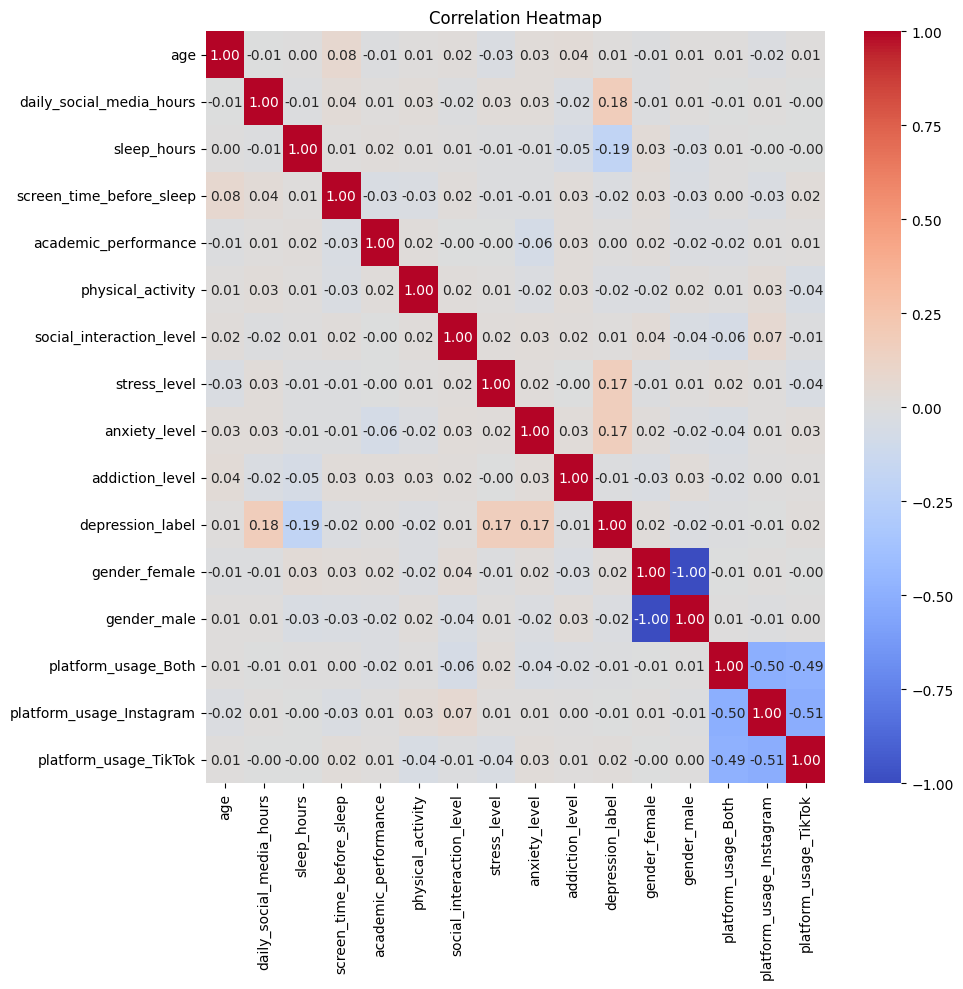

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

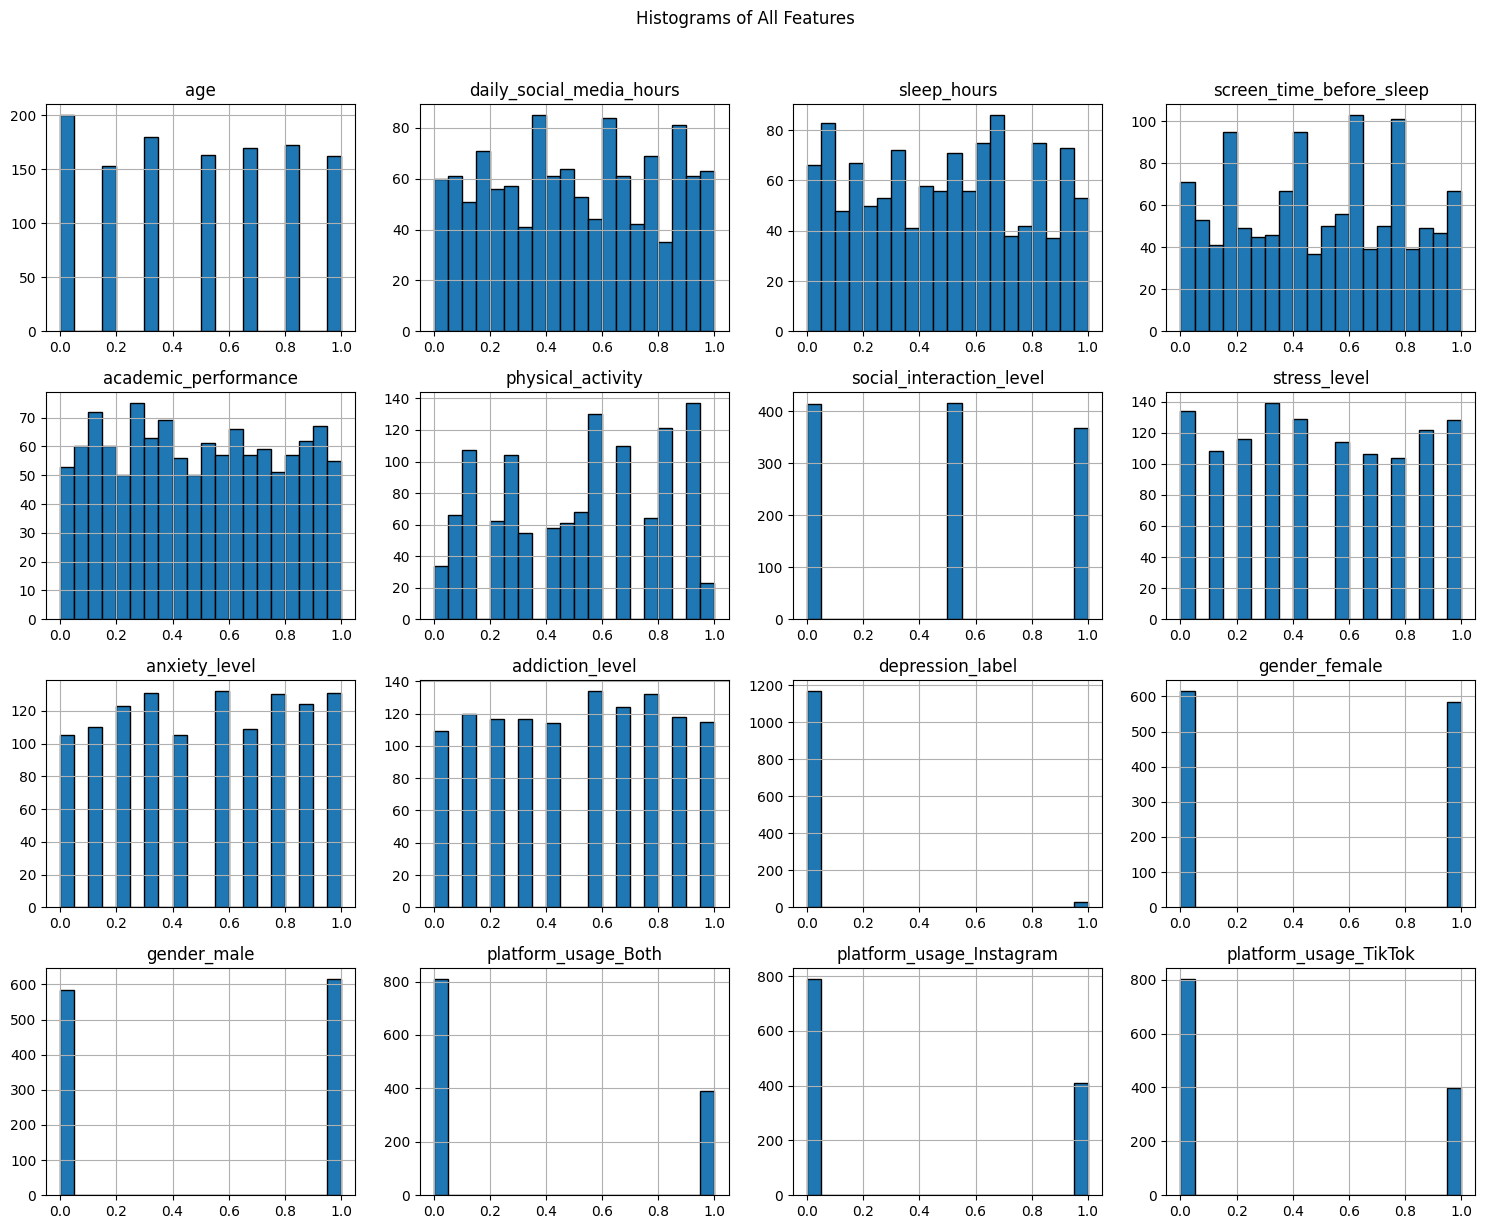

In [ ]:
#Histogram all features
df.hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout()
plt.show()

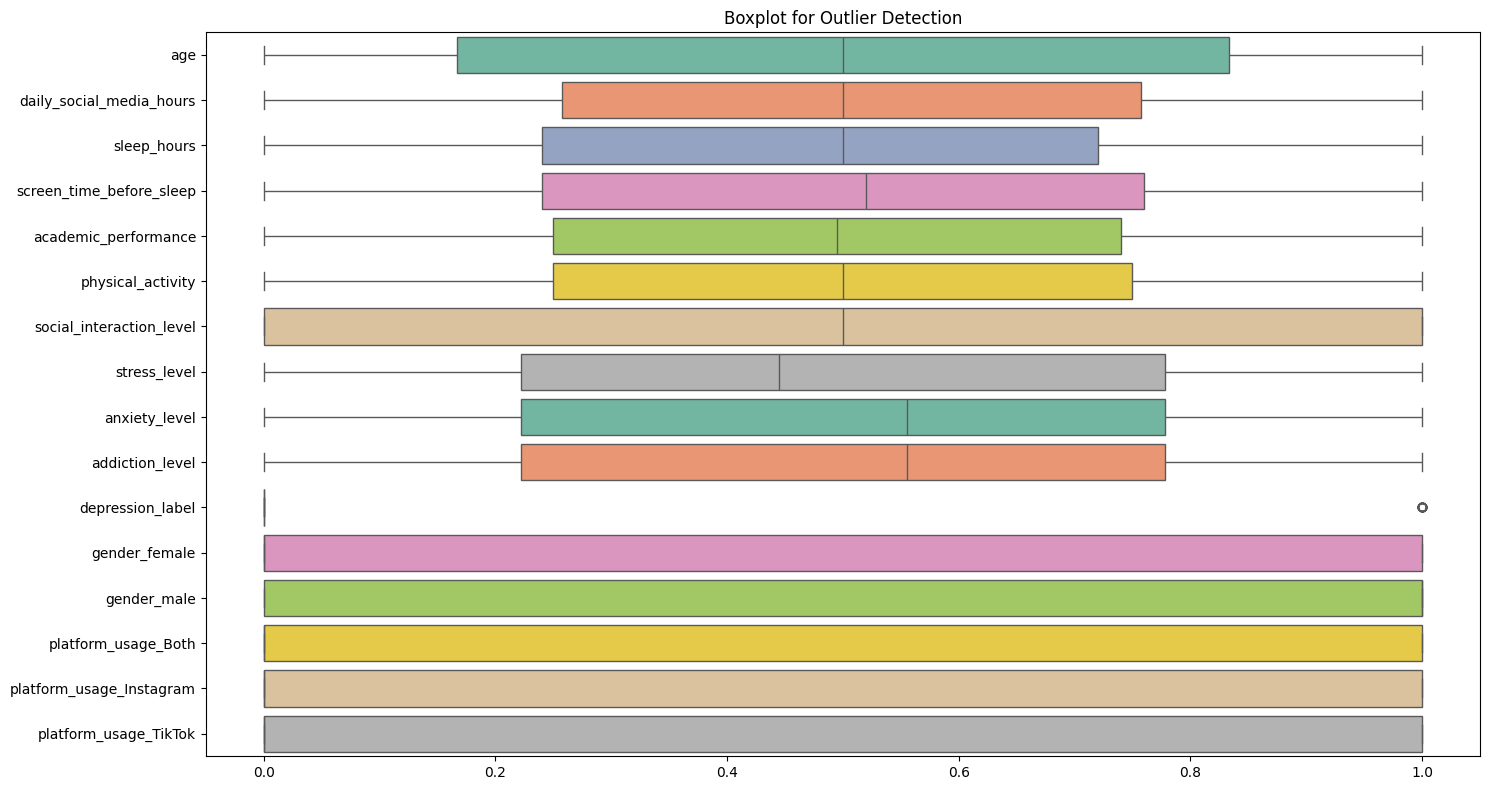

In [ ]:
#Boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient='h', palette='Set2')
plt.title('Boxplot for Outlier Detection')
plt.tight_layout()
plt.show()

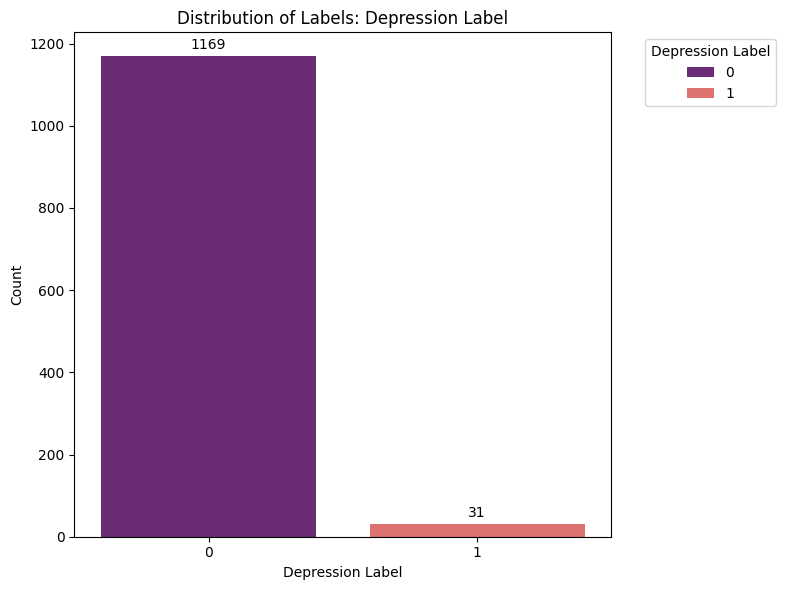

In [ ]:
#Countplot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='depression_label', hue='depression_label', data=df, palette='magma')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Distribution of Labels: Depression Label')
plt.xlabel('Depression Label')
plt.ylabel('Count')
plt.legend(title='Depression Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**BUILD MODEL**

In [ ]:
#criterion = gini
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
dt_gini.fit(X_train, y_train)

y_pred_train_gini = dt_gini.predict(X_train)
y_pred_test_gini = dt_gini.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_gini))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_gini))
print(classification_report(y_test, y_pred_test_gini))

Training Accuracy: 1.0
Testing Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



In [ ]:
#Criterion = entropy
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
dt_entropy.fit(X_train, y_train)

y_pred_train_entropy = dt_entropy.predict(X_train)
y_pred_test_entropy = dt_entropy.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_entropy))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_entropy))
print(classification_report(y_test, y_pred_test_entropy))

Training Accuracy: 1.0
Testing Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**TRAINING**

      METRICS
Accuracy:  0.9917
Precision: 0.8333
Recall:    0.8333
F1-score:  0.8333
                       CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



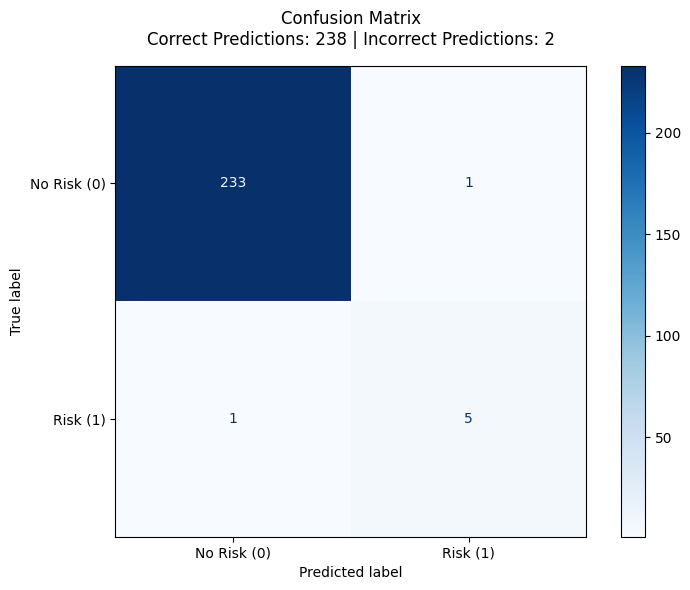

In [ ]:
y_pred = dt_gini.predict(X_test)
y_prob = dt_gini.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("      METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("                       CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
correct_preds = cm[0, 0] + cm[1, 1]
incorrect_preds = cm[0, 1] + cm[1, 0]

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk (0)', 'Risk (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title(f'Confusion Matrix\nCorrect Predictions: {correct_preds} | Incorrect Predictions: {incorrect_preds}', pad=15)
plt.tight_layout()
plt.show()

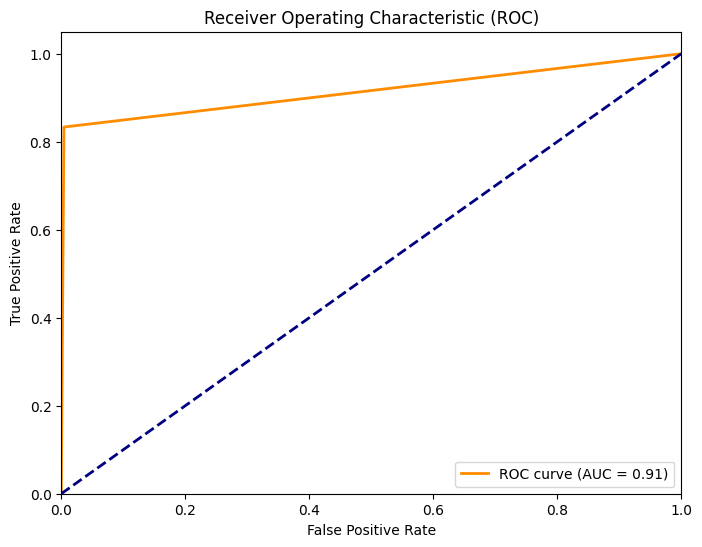

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_
best_params = grid_search.best_params_

y_pred_best = best_dt_model.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print("BEST PARAMETERS:")
print(best_params)

print("\n         OPTIMISED MODEL METRICS:")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1-score: {best_f1:.4f}")

print("\n         CLASSIFICATION REPORT (OPTIMISED):")
print(classification_report(y_test, y_pred_best))

BEST PARAMETERS:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}

         OPTIMISED MODEL METRICS:
Accuracy: 1.0000
F1-score: 1.0000

         CLASSIFICATION REPORT (OPTIMISED):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

